In [1]:
"""
Hybrid RetNet Model: Masked Nucleotide Prediction (M+R)
-------------------------------------------------------
Dataset: Salmonella Typhimurium (11 genomes)

Input files:
- train_mr.txt : 10 genomes, masked+replaced sequences (inputs)
- train.txt    : 10 genomes, raw sequences (targets)
- test_mr.txt  : Salmonella 11, masked+replaced sequences (inputs)
- test.txt     : Salmonella 11, raw sequences (targets)

Masking Strategy:
- Pattern: i % 5 == (i // 5) % 5 (same as transformer)
- 85% masked with M, 15% replaced with wrong nucleotide
- Seed 42 for reproducibility

Model Architecture (Hybrid RetNet):
- 5-mer tokenisation (1027 tokens)
- 3 x RetNet layers (retention mechanism - parallel O(n))
- 1 x Transformer attention layer (final decision making)
- Embedding dim : 128, Window size: 128 (5-mers)

Data Split:
- 85% of training data for training
- 15% of training data for validation (early stopping)
- Test set (Salmonella 11) completely untouched until evaluation

Training:
- Optimiser : AdamW
- Loss      : Cross Entropy (masked + replaced positions only)
- Early stopping patience: 2
- Device    : CUDA if available, else CPU
"""


'\nHybrid RetNet Model: Masked Nucleotide Prediction (M+R)\n-------------------------------------------------------\nDataset: Salmonella Typhimurium (11 genomes)\n\nInput files:\n- train_mr.txt : 10 genomes, masked+replaced sequences (inputs)\n- train.txt    : 10 genomes, raw sequences (targets)\n- test_mr.txt  : Salmonella 11, masked+replaced sequences (inputs)\n- test.txt     : Salmonella 11, raw sequences (targets)\n\nMasking Strategy:\n- Pattern: i % 5 == (i // 5) % 5 (same as transformer)\n- 85% masked with M, 15% replaced with wrong nucleotide\n- Seed 42 for reproducibility\n\nModel Architecture (Hybrid RetNet):\n- 5-mer tokenisation (1027 tokens)\n- 3 x RetNet layers (retention mechanism - parallel O(n))\n- 1 x Transformer attention layer (final decision making)\n- Embedding dim : 128, Window size: 128 (5-mers)\n\nData Split:\n- 85% of training data for training\n- 15% of training data for validation (early stopping)\n- Test set (Salmonella 11) completely untouched until evaluat

Step 1 - Imports

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import itertools
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# ── Reproducibility seeds ─────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
print(f"  Seed set to {SEED}")


  Seed set to 42


Step 2 - Hyperparameters

In [3]:
# ── Build 5-mer vocabulary ────────────────────────────────────────────────────
bases    = ["A", "C", "G", "T"]
kmers    = ["".join(k) for k in itertools.product(bases, repeat=5)]
kmer2idx = {kmer: idx for idx, kmer in enumerate(kmers)}
kmer2idx["MASK"] = 1024
kmer2idx["PAD"]  = 1025
kmer2idx["UNK"]  = 1026
VOCAB      = kmer2idx
VOCAB_SIZE = len(VOCAB)  # 1027

# ── Windowing ─────────────────────────────────────────────────────────────────
WINDOW_SIZE = 128
STRIDE      = 64

# ── Model Architecture ────────────────────────────────────────────────────────
EMBED_DIM   = 128
NUM_HEADS   = 4
NUM_LAYERS  = 3
FF_DIM      = 256
DROPOUT     = 0.1
# Retention decay factors — one per head, controls memory length
GAMMAS      = [1 - 2**(-5 - i) for i in range(NUM_HEADS)]  # [0.96875, 0.984375, 0.9921875, 0.99609375]

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE    = 64
EPOCHS        = 20
LEARNING_RATE = 3e-4

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  Vocabulary size : {VOCAB_SIZE}")
print(f"  Window size     : {WINDOW_SIZE}")
print(f"  Gammas          : {[round(g, 4) for g in GAMMAS]}")
print(f"  Device          : {DEVICE}")


  Vocabulary size : 1027
  Window size     : 128
  Gammas          : [0.9688, 0.9844, 0.9922, 0.9961]
  Device          : cuda


Step 3 - Dataset

In [4]:
class DNADataset(Dataset):
    def __init__(self, masked_path, original_path, window_size=WINDOW_SIZE, stride=STRIDE):
        self.windows_input  = []
        self.windows_target = []

        masked_seqs   = open(masked_path,   "r").readlines()
        original_seqs = open(original_path, "r").readlines()

        for masked_seq, original_seq in zip(masked_seqs, original_seqs):
            masked_seq   = masked_seq.strip().upper()
            original_seq = original_seq.strip().upper()

            masked_kmers = []
            for i in range(0, len(masked_seq) - 4, 1):
                kmer = masked_seq[i:i+5]
                if "M" in kmer:
                    masked_kmers.append(VOCAB["MASK"])
                elif "N" in kmer:
                    masked_kmers.append(VOCAB["UNK"])
                else:
                    masked_kmers.append(VOCAB.get(kmer, VOCAB["UNK"]))

            original_kmers = []
            for i in range(0, len(original_seq) - 4, 1):
                kmer = original_seq[i:i+5]
                if "N" in kmer:
                    original_kmers.append(VOCAB["UNK"])
                else:
                    original_kmers.append(VOCAB.get(kmer, VOCAB["UNK"]))

            for start in range(0, len(original_kmers) - window_size, stride):
                inp = masked_kmers  [start : start + window_size]
                tgt = original_kmers[start : start + window_size]
                self.windows_input.append(torch.tensor(inp, dtype=torch.long))
                self.windows_target.append(torch.tensor(tgt, dtype=torch.long))

    def __len__(self):
        return len(self.windows_input)

    def __getitem__(self, idx):
        return self.windows_input[idx], self.windows_target[idx]


# ── Load full training set then split 85/15 into train/val ───────────────────
full_train   = DNADataset("train_mr.txt", "train.txt")
test_dataset = DNADataset("test_mr.txt",  "test.txt")

train_size = int(0.85 * len(full_train))
val_size   = len(full_train) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"  Total train windows  : {len(full_train):,}")
print(f"  Train split (85%)    : {len(train_dataset):,}")
print(f"  Val split   (15%)    : {len(val_dataset):,}")
print(f"  Test windows         : {len(test_dataset):,}")


  Total train windows  : 775,244
  Train split (85%)    : 658,957
  Val split   (15%)    : 116,287
  Test windows         : 77,075


Step 4 - RetNet Model

In [5]:
# ── Retention Mechanism ───────────────────────────────────────────────────────
class MultiScaleRetention(nn.Module):
    def __init__(self, embed_dim, num_heads, gammas, dropout=DROPOUT):
        super().__init__()
        self.embed_dim  = embed_dim
        self.num_heads  = num_heads
        self.head_dim   = embed_dim // num_heads
        self.gammas     = gammas
        self.q_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.k_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.v_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.o_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("D", self._build_decay_matrix())

    def _build_decay_matrix(self):
        n = WINDOW_SIZE
        D = torch.zeros(self.num_heads, n, n)
        for h, gamma in enumerate(self.gammas):
            for i in range(n):
                for j in range(i + 1):
                    D[h, i, j] = gamma ** (i - j)
        return D

    def forward(self, x):
        batch, seq_len, _ = x.shape
        Q = self.q_proj(x).view(batch, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(batch, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(batch, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        D   = self.D[:, :seq_len, :seq_len]
        QK  = torch.matmul(Q, K.transpose(-2, -1)) * D.unsqueeze(0) / (seq_len ** 0.5)
        out = torch.matmul(QK, V)
        out = out.transpose(1, 2).contiguous().view(batch, seq_len, self.embed_dim)
        return self.dropout(self.o_proj(out))


# ── RetNet Block ──────────────────────────────────────────────────────────────
class RetNetBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, gammas, ff_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.norm1     = nn.LayerNorm(embed_dim)
        self.norm2     = nn.LayerNorm(embed_dim)
        self.retention = MultiScaleRetention(embed_dim, num_heads, gammas, dropout)
        self.ff        = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.retention(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x


# ── Transformer Attention Block ───────────────────────────────────────────────
class AttentionBlock(nn.Module):
    def __init__(self, embed_dim, num_heads=NUM_HEADS, ff_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.ff    = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed)
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return x


# ── Hybrid RetNet Model (3 RetNet + 1 Attention) ──────────────────────────────
class HybridRetNetModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding     = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=VOCAB["PAD"])
        self.pos_embedding = nn.Embedding(WINDOW_SIZE, EMBED_DIM)
        self.layers = nn.ModuleList([
            RetNetBlock   (EMBED_DIM, NUM_HEADS, GAMMAS),  # Layer 1 - RetNet
            RetNetBlock   (EMBED_DIM, NUM_HEADS, GAMMAS),  # Layer 2 - RetNet
            RetNetBlock   (EMBED_DIM, NUM_HEADS, GAMMAS),  # Layer 3 - RetNet
            AttentionBlock(EMBED_DIM),                     # Layer 4 - Attention
        ])
        self.norm         = nn.LayerNorm(EMBED_DIM)
        self.output_layer = nn.Linear(EMBED_DIM, VOCAB_SIZE)

    def forward(self, x):
        positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)
        x = self.embedding(x) + self.pos_embedding(positions)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        return self.output_layer(x)


model = HybridRetNetModel().to(DEVICE)
print(model)
print(f"\n  Total parameters: {sum(p.numel() for p in model.parameters()):,}")


HybridRetNetModel(
  (embedding): Embedding(1027, 128, padding_idx=1025)
  (pos_embedding): Embedding(128, 128)
  (layers): ModuleList(
    (0-2): 3 x RetNetBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (retention): MultiScaleRetention(
        (q_proj): Linear(in_features=128, out_features=128, bias=False)
        (k_proj): Linear(in_features=128, out_features=128, bias=False)
        (v_proj): Linear(in_features=128, out_features=128, bias=False)
        (o_proj): Linear(in_features=128, out_features=128, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=256, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (3): AttentionB

Step 5 - Training

In [6]:
PATIENCE         = 2
best_loss        = float("inf")
patience_counter = 0

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0; total_correct = 0; total_masked = 0
    for input_kmers, target_kmers in loader:
        input_kmers  = input_kmers.to(DEVICE)
        target_kmers = target_kmers.to(DEVICE)
        optimizer.zero_grad()
        output         = model(input_kmers)
        mask           = (input_kmers == VOCAB["MASK"]) | (input_kmers != target_kmers)
        masked_output  = output[mask]
        masked_targets = target_kmers[mask]
        loss           = criterion(masked_output, masked_targets)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item()
        predictions    = masked_output.argmax(dim=-1)
        total_correct += (predictions == masked_targets).sum().item()
        total_masked  += mask.sum().item()
    return total_loss / len(loader), total_correct / total_masked * 100


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0; total_correct = 0; total_masked = 0
    with torch.no_grad():
        for input_kmers, target_kmers in loader:
            input_kmers  = input_kmers.to(DEVICE)
            target_kmers = target_kmers.to(DEVICE)
            output         = model(input_kmers)
            mask           = (input_kmers == VOCAB["MASK"]) | (input_kmers != target_kmers)
            masked_output  = output[mask]
            masked_targets = target_kmers[mask]
            loss           = criterion(masked_output, masked_targets)
            total_loss    += loss.item()
            predictions    = masked_output.argmax(dim=-1)
            total_correct += (predictions == masked_targets).sum().item()
            total_masked  += mask.sum().item()
    return total_loss / len(loader), total_correct / total_masked * 100


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)  # val set only
    print(f"  Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    scheduler.step(val_loss)
    if val_loss < best_loss:
        best_loss        = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "hybrid_retnet_best_mr.pth")
        print(f"  --> Best model saved at epoch {epoch}")
    else:
        patience_counter += 1
        print(f"  --> No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"  Early stopping triggered at epoch {epoch}!")
            break


  Epoch 01/20 | Train Loss: 3.3455 | Train Acc: 18.89% | Val Loss: 1.6794 | Val Acc: 32.14%
  --> Best model saved at epoch 1
  Epoch 02/20 | Train Loss: 1.7237 | Train Acc: 30.98% | Val Loss: 1.6026 | Val Acc: 33.96%
  --> Best model saved at epoch 2
  Epoch 03/20 | Train Loss: 1.6453 | Train Acc: 32.81% | Val Loss: 1.5792 | Val Acc: 34.96%
  --> Best model saved at epoch 3
  Epoch 04/20 | Train Loss: 1.6159 | Train Acc: 33.90% | Val Loss: 1.5628 | Val Acc: 35.75%
  --> Best model saved at epoch 4
  Epoch 05/20 | Train Loss: 1.5975 | Train Acc: 34.66% | Val Loss: 1.5527 | Val Acc: 36.22%
  --> Best model saved at epoch 5
  Epoch 06/20 | Train Loss: 1.5856 | Train Acc: 35.14% | Val Loss: 1.5465 | Val Acc: 36.53%
  --> Best model saved at epoch 6
  Epoch 07/20 | Train Loss: 1.5773 | Train Acc: 35.48% | Val Loss: 1.5417 | Val Acc: 36.72%
  --> Best model saved at epoch 7
  Epoch 08/20 | Train Loss: 1.5707 | Train Acc: 35.78% | Val Loss: 1.5379 | Val Acc: 36.95%
  --> Best model saved at 

Step 6 - Evaluation

  EVALUATION RESULTS — Test Set (Unseen Genome)
  Test Loss                        : 1.4970
  Test Accuracy (5-mer token)       : 38.92%
  Test Accuracy (single nucleotide) : 85.44%
  Total masked positions            : 8,287,104

  Classification Report (per nucleotide):
              precision    recall  f1-score   support

           A     0.8562    0.8422    0.8491   1983909
           T     0.8455    0.8466    0.8461   1982120
           G     0.8633    0.8592    0.8612   2158096
           C     0.8520    0.8679    0.8599   2162979

    accuracy                         0.8544   8287104
   macro avg     0.8543    0.8540    0.8541   8287104
weighted avg     0.8544    0.8544    0.8544   8287104



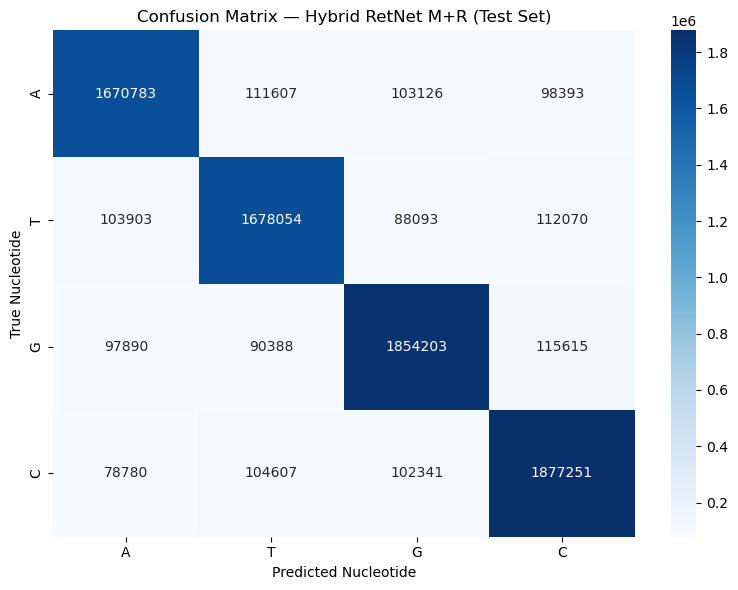

  Confusion matrix saved as confusion_matrix_hybrid_retnet_mr.png


In [7]:
# Load best model
model.load_state_dict(torch.load("hybrid_retnet_best_mr.pth", map_location=DEVICE))
model.eval()

all_preds   = []
all_targets = []
total_correct = 0
total_masked  = 0
total_loss    = 0

idx2kmer = {v: k for k, v in VOCAB.items() if len(k) == 5}
def kmer_to_nuc(idx):
    kmer = idx2kmer.get(idx, "N")
    return kmer[0] if kmer != "N" else "N"

with torch.no_grad():
    for input_kmers, target_kmers in test_loader:
        input_kmers  = input_kmers.to(DEVICE)
        target_kmers = target_kmers.to(DEVICE)
        output         = model(input_kmers)
        mask           = (input_kmers == VOCAB["MASK"]) | (input_kmers != target_kmers)
        masked_output  = output[mask]
        masked_targets = target_kmers[mask]
        loss           = criterion(masked_output, masked_targets)
        total_loss    += loss.item()
        predictions    = masked_output.argmax(dim=-1)
        total_correct += (predictions == masked_targets).sum().item()   # 5-mer match
        total_masked  += mask.sum().item()
        all_preds.extend  ([kmer_to_nuc(p.item()) for p in predictions])
        all_targets.extend([kmer_to_nuc(t.item()) for t in masked_targets])

test_accuracy_5mer = total_correct / total_masked * 100
test_loss           = total_loss / len(test_loader)

nucleotide_correct  = sum(1 for p, t in zip(all_preds, all_targets) if p == t)
nucleotide_total    = len(all_targets)
test_accuracy_nuc   = nucleotide_correct / nucleotide_total * 100

print("=" * 60)
print("  EVALUATION RESULTS — Test Set (Unseen Genome)")
print("=" * 60)
print(f"  Test Loss                        : {test_loss:.4f}")
print(f"  Test Accuracy (5-mer token)       : {test_accuracy_5mer:.2f}%")
print(f"  Test Accuracy (single nucleotide) : {test_accuracy_nuc:.2f}%")
print(f"  Total masked positions            : {total_masked:,}")
print("=" * 60)

print("\n  Classification Report (per nucleotide):")
print(classification_report(all_targets, all_preds, labels=["A", "T", "G", "C"], digits=4))

labels = ["A", "T", "G", "C"]
cm = confusion_matrix(all_targets, all_preds, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — Hybrid RetNet M+R (Test Set)")
plt.xlabel("Predicted Nucleotide")
plt.ylabel("True Nucleotide")
plt.tight_layout()
plt.savefig("confusion_matrix_hybrid_retnet_mr.png", dpi=150)
plt.show()
print("  Confusion matrix saved as confusion_matrix_hybrid_retnet_mr.png")

Step 7 - ROC Curve

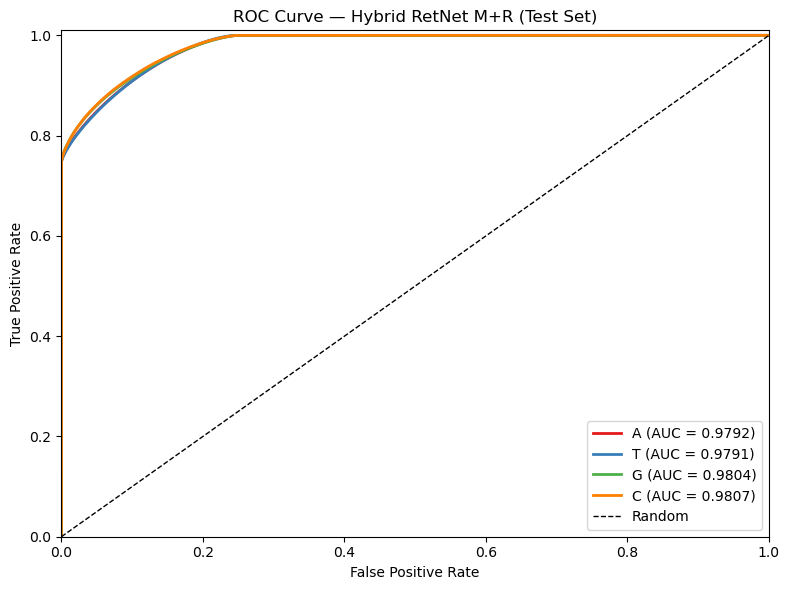

  ROC curve saved as roc_curve_hybrid_retnet_mr.png


In [8]:
model.eval()
all_probs  = []
all_true   = []
nuc_labels = ["A", "T", "G", "C"]
nuc_to_idx = {"A": 0, "T": 1, "G": 2, "C": 3}

with torch.no_grad():
    for input_kmers, target_kmers in test_loader:
        input_kmers  = input_kmers.to(DEVICE)
        target_kmers = target_kmers.to(DEVICE)
        output       = model(input_kmers)
        mask         = (input_kmers == VOCAB["MASK"])
        masked_output  = output[mask]
        masked_targets = target_kmers[mask]

        probs = torch.softmax(masked_output, dim=-1).cpu().numpy()
        tgts  = masked_targets.cpu().numpy()

        nuc_probs = np.zeros((probs.shape[0], 4))
        for nuc_i, nuc in enumerate(nuc_labels):
            kmer_indices = [v for k, v in VOCAB.items() if len(k) == 5 and k[0] == nuc]
            nuc_probs[:, nuc_i] = probs[:, kmer_indices].sum(axis=1)

        true_nucs = [kmer_to_nuc(t) for t in tgts]
        true_idxs = [nuc_to_idx.get(n, 0) for n in true_nucs]

        all_probs.extend(nuc_probs.tolist())
        all_true.extend(true_idxs)

all_probs    = np.array(all_probs)
all_true     = np.array(all_true)
all_true_bin = label_binarize(all_true, classes=[0, 1, 2, 3])

colors = ["#e41a1c", "#377eb8", "#4daf4a", "#ff7f00"]
plt.figure(figsize=(8, 6))

for i, (nuc, color) in enumerate(zip(nuc_labels, colors)):
    fpr, tpr, _ = roc_curve(all_true_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{nuc} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Hybrid RetNet M+R (Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_hybrid_retnet_mr.png", dpi=150)
plt.show()
print("  ROC curve saved as roc_curve_hybrid_retnet_mr.png")
